<a href="https://colab.research.google.com/github/sonjoy1s/ML/blob/main/Diabetes_prediction_dataset_for_Paper.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder , OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
#from catboost import CatBoostClassifier
#from lightgbm import LGBMClassifier
from sklearn.ensemble import VotingClassifier, StackingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [9]:
df = pd.read_csv("/content/diabetes_prediction_dataset.csv.zip")
df

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0
...,...,...,...,...,...,...,...,...,...
99995,Female,80.0,0,0,No Info,27.32,6.2,90,0
99996,Female,2.0,0,0,No Info,17.37,6.5,100,0
99997,Male,66.0,0,0,former,27.83,5.7,155,0
99998,Female,24.0,0,0,never,35.42,4.0,100,0


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB


In [11]:
df.columns

Index(['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history',
       'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes'],
      dtype='object')

In [12]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,100000.0,41.885856,22.516840,0.08,24.00,43.00,60.00,80.00
hypertension,100000.0,0.074850,0.263150,0.00,0.00,0.00,0.00,1.00
heart_disease,100000.0,0.039420,0.194593,0.00,0.00,0.00,0.00,1.00
bmi,100000.0,27.320767,6.636783,10.01,23.63,27.32,29.58,95.69
HbA1c_level,100000.0,5.527507,1.070672,3.50,4.80,5.80,6.20,9.00
blood_glucose_level,100000.0,138.058060,40.708136,80.00,100.00,140.00,159.00,300.00
diabetes,100000.0,0.085000,0.278883,0.00,0.00,0.00,0.00,1.00


In [13]:
df.isna().sum()

,0
gender,0
age,0
hypertension,0
heart_disease,0
smoking_history,0
bmi,0
HbA1c_level,0
blood_glucose_level,0
diabetes,0


In [24]:
df.nunique()

,0
gender,3
age,102
hypertension,2
heart_disease,2
smoking_history,6
bmi,4247
HbA1c_level,18
blood_glucose_level,18
diabetes,2


In [14]:
X = df.drop(columns=['diabetes'],axis=1)
y = df['diabetes']

In [15]:
numerical_cols  = X.select_dtypes(include=np.number).columns

print(numerical_cols)

categorical_cols = X.select_dtypes(include=object).columns

print(categorical_cols)

Index(['age', 'hypertension', 'heart_disease', 'bmi', 'HbA1c_level',
       'blood_glucose_level'],
      dtype='object')
Index(['gender', 'smoking_history'], dtype='object')


Boxplot For Outliear Handling

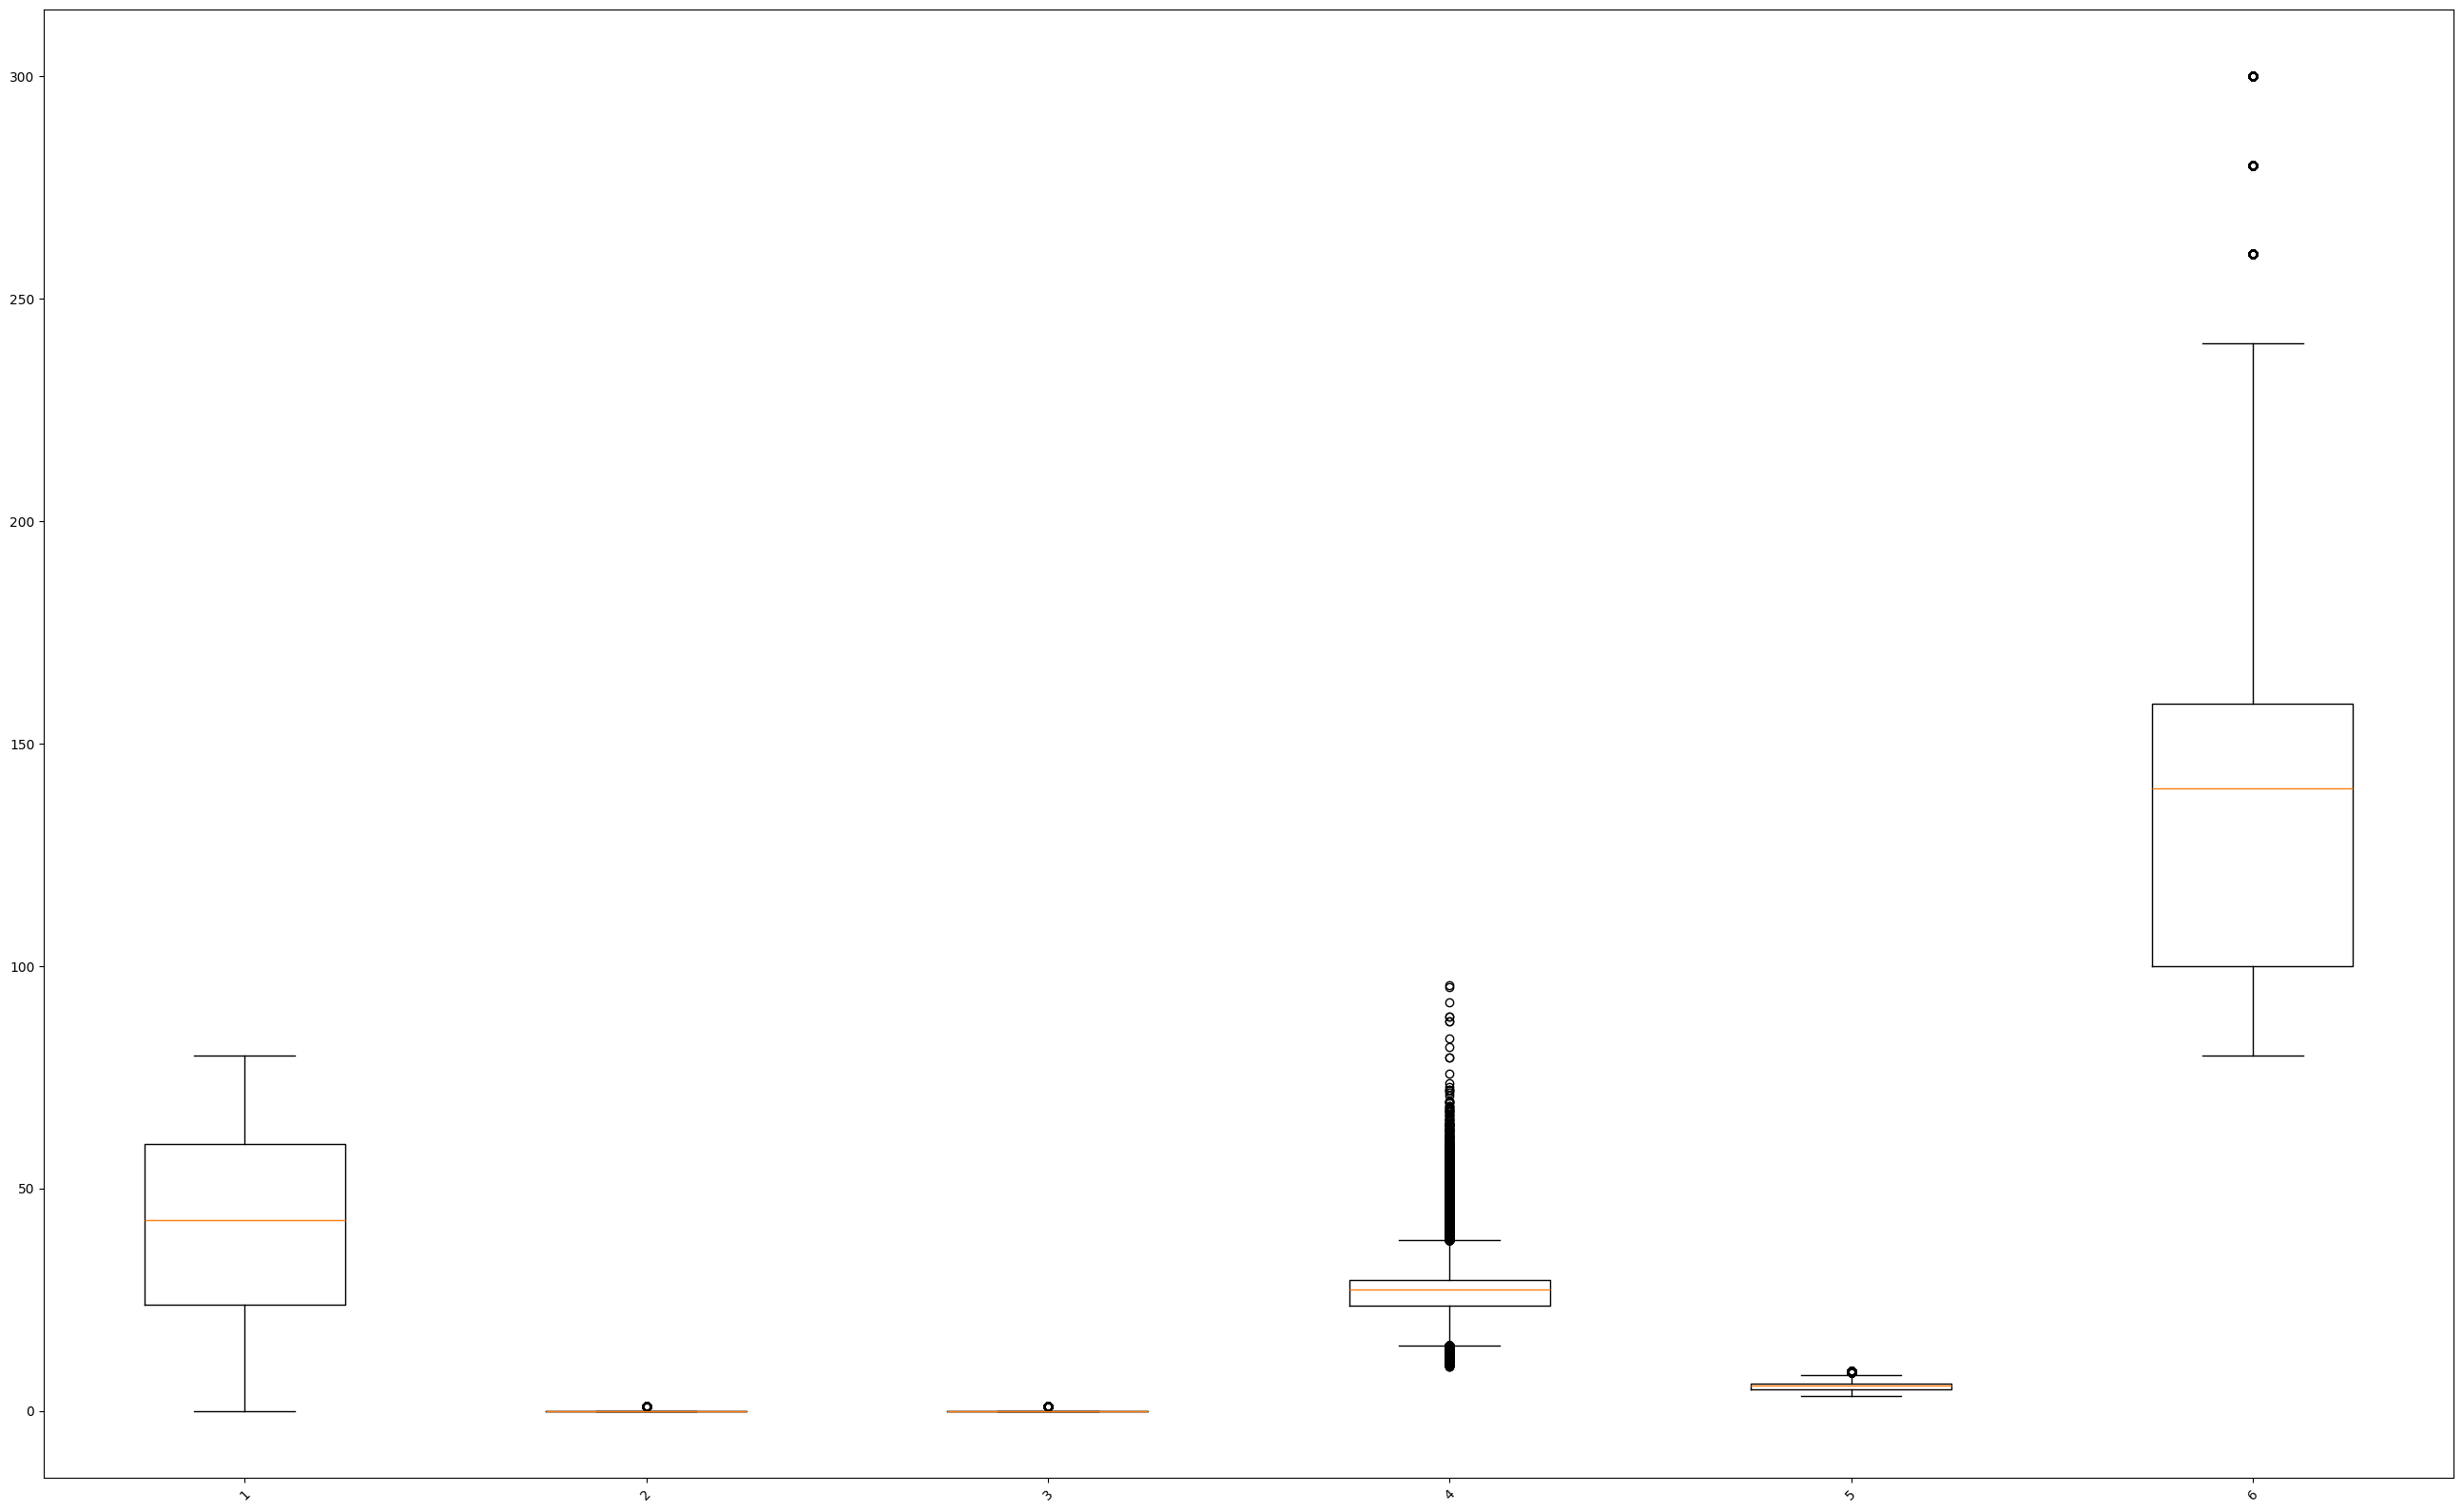

In [16]:
plt.figure(figsize=(26,16))
plt.boxplot(df[numerical_cols])
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# TargetColumns correlation All Columns Heatmap

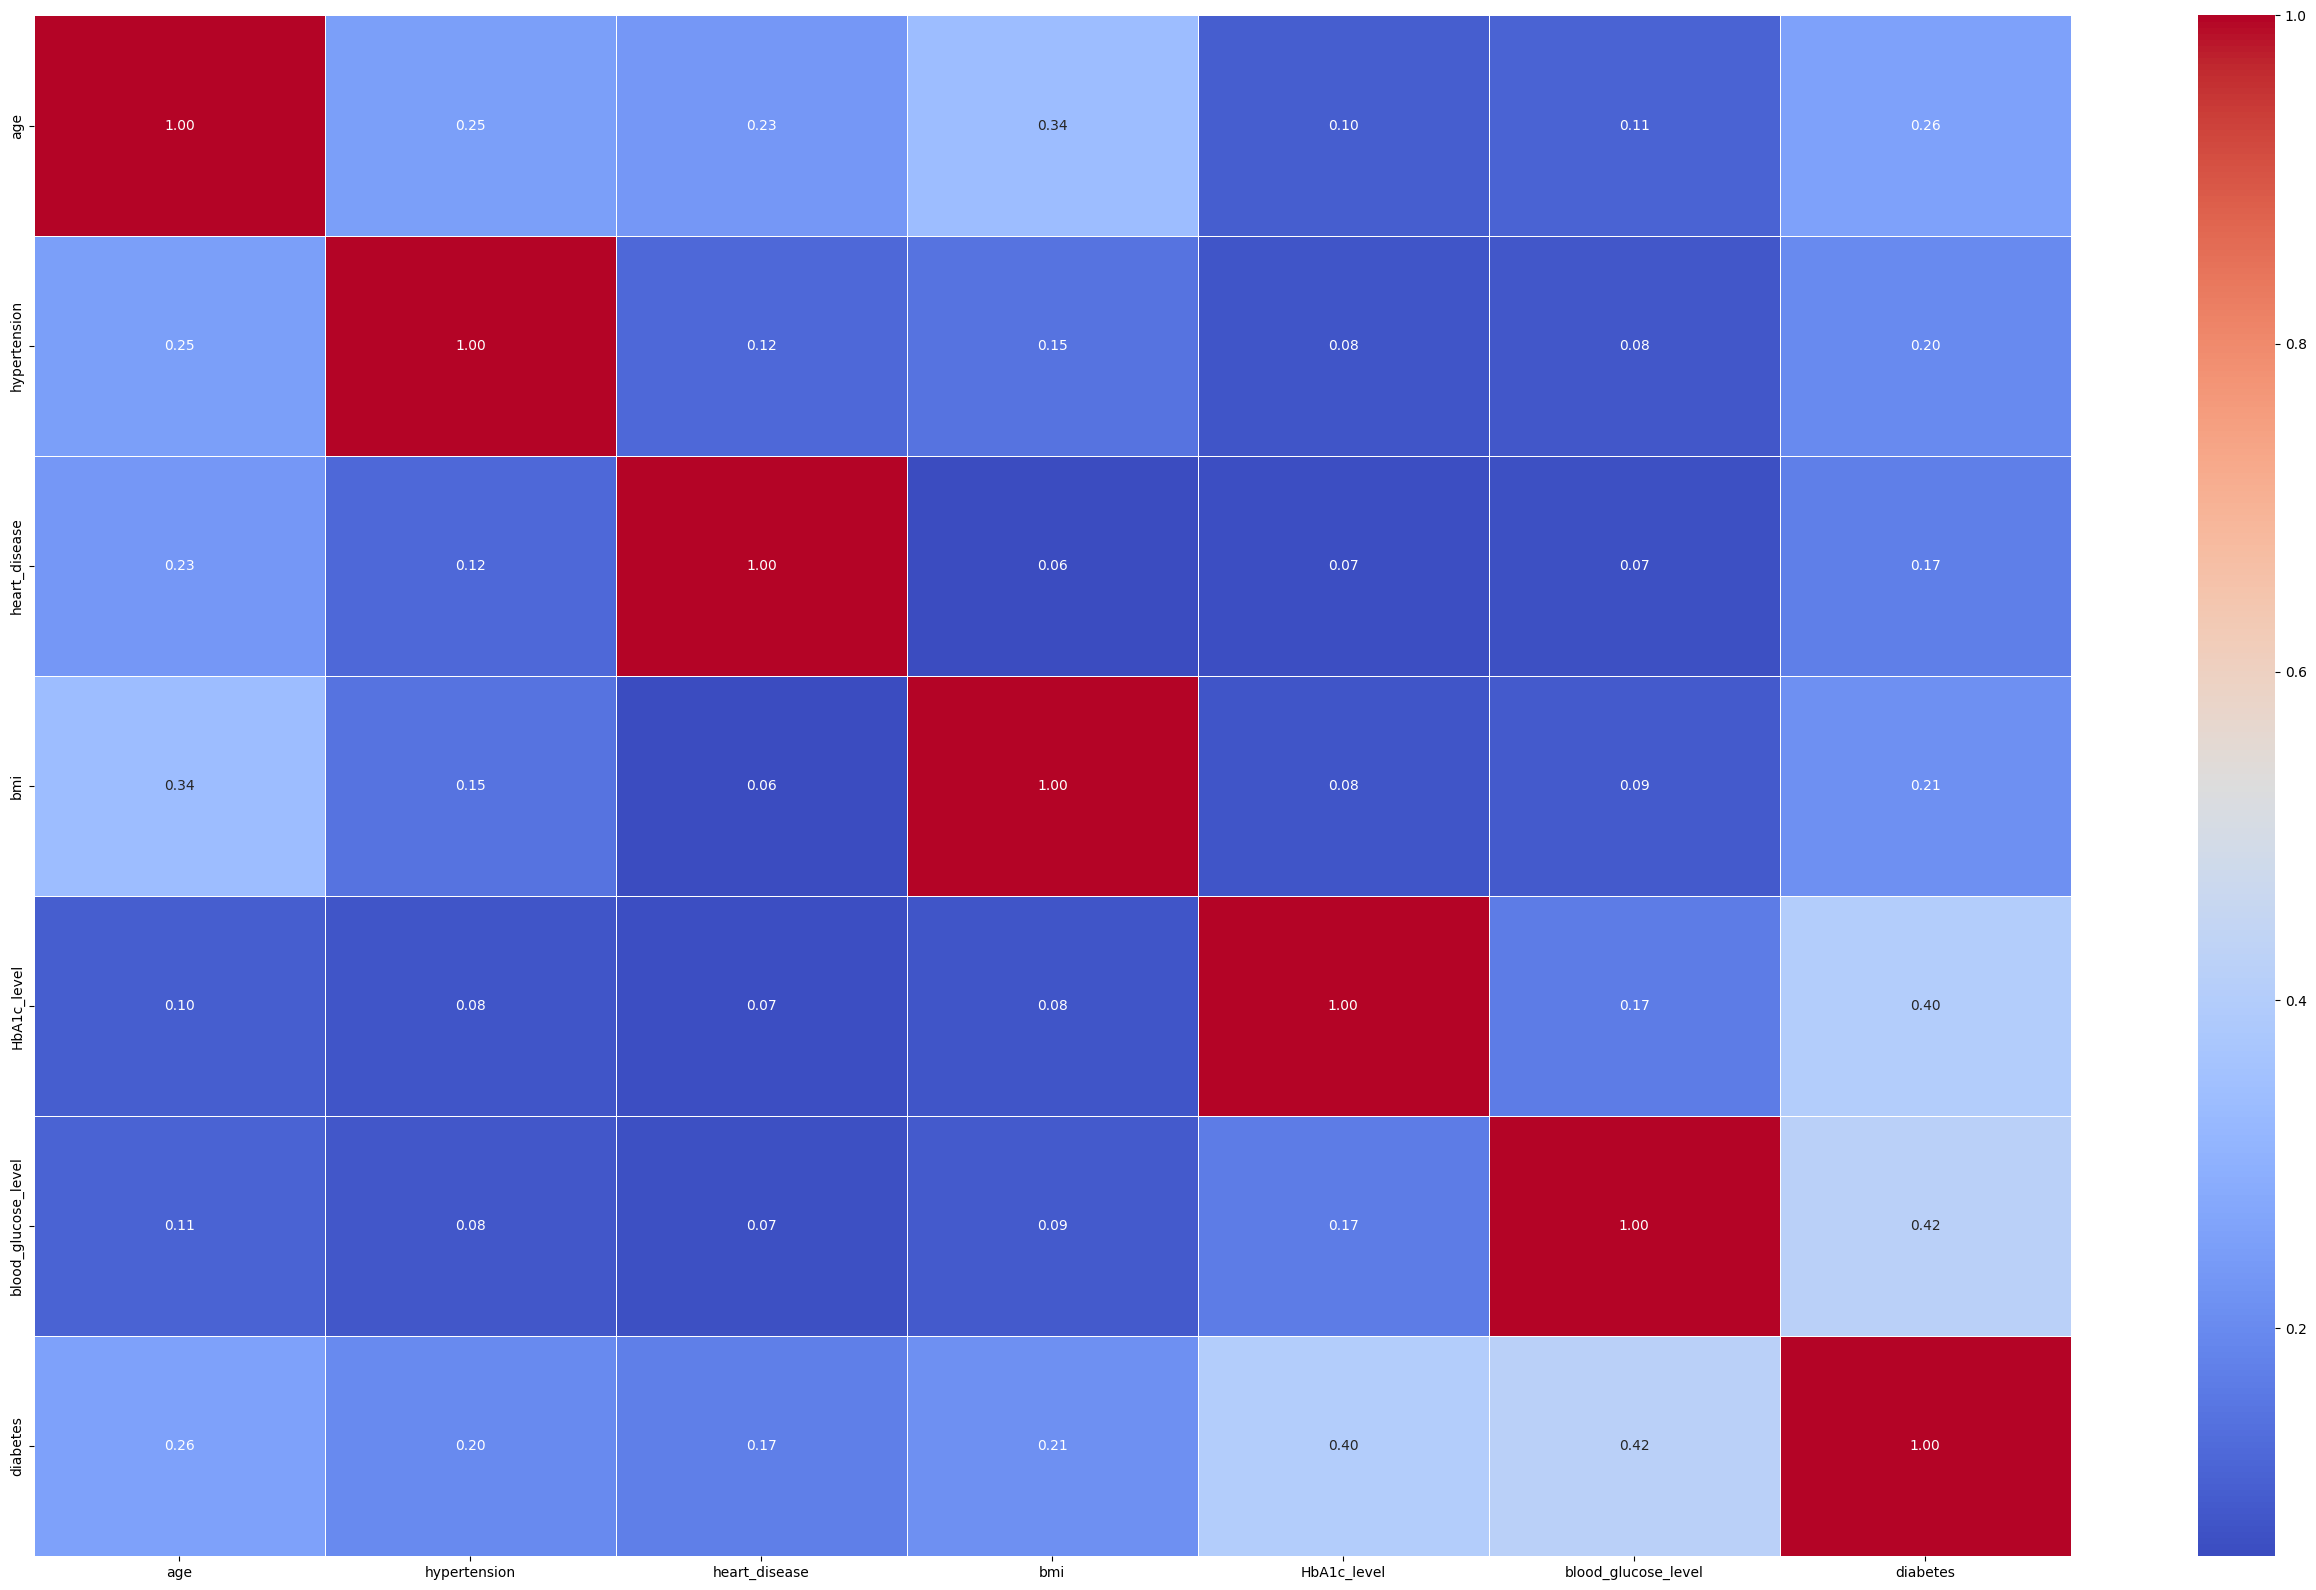

In [18]:
target_col ='diabetes'
plt.figure(figsize=(26,16))
corr_matrix = df[list(numerical_cols) + [target_col]].corr()
sns.heatmap(corr_matrix,annot=True,cmap='coolwarm',fmt='.2f',linewidth=0.5)
plt.tight_layout()
plt.show()

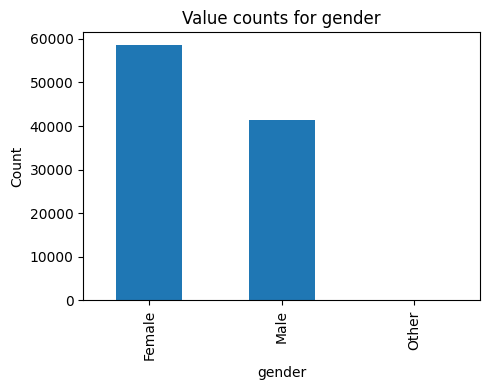

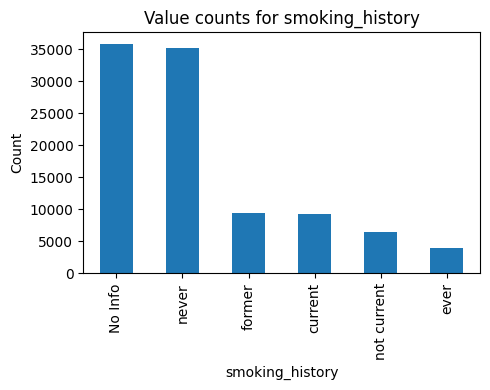

In [19]:
for c in categorical_cols:
  plt.figure(figsize=(5,4))
  df[c].value_counts().plot(kind="bar")
  plt.title(f"Value counts for {c}")
  plt.ylabel("Count")
  plt.tight_layout()
  plt.show()

In [20]:
df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


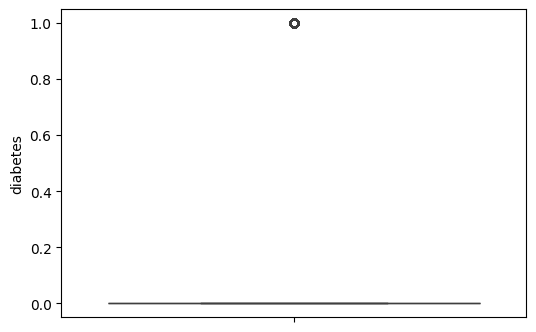

In [21]:
plt.figure(figsize=(6,4))
sns.boxplot(df['diabetes'])
plt.show()

In [23]:
for col in categorical_cols:
    print(f"Unique values for '{col}': {df[col].unique()}")

Unique values for 'gender': ['Female' 'Male' 'Other']
Unique values for 'smoking_history': ['never' 'No Info' 'current' 'former' 'ever' 'not current']


In [25]:
#numerical Pipeline
numerical_pipe = Pipeline(
    steps=[
        ('imputer',SimpleImputer(strategy='median')),
        ('scaler',StandardScaler())
    ]
)

In [26]:
categorical_pipe = Pipeline(
    steps=[
        ('imputer',SimpleImputer(strategy='most_frequent')),
        ('onehot',OneHotEncoder(handle_unknown='ignore'))
    ]
)

In [27]:
#Combine numerical and categorical

from sklearn.compose import ColumnTransformer
Combine_pipe = ColumnTransformer([
    ('num',numerical_pipe,numerical_cols),
    ('cat',categorical_pipe,categorical_cols)
]
)

In [28]:
X_train,X_test, y_train, y_test = train_test_split(X,y, test_size = 0.25 , random_state=42,stratify=y)

In [29]:
# base Learner
lr = LogisticRegression()
dt = DecisionTreeClassifier()
rf = RandomForestClassifier()
gb = GradientBoostingClassifier()
xgb = XGBClassifier()
#lgb = LGBMClassifier()
#cat = CatBoostClassifier()

In [37]:
#voting Classification
voting_cls = VotingClassifier(
    estimators=[
        ('lr',lr),
        ('dt',dt),
        ('rf',rf),
        ('gb',gb),
        ('xgb',xgb)

    ],
    voting='soft'
)

In [31]:
#Stacking

stacking_cls = StackingClassifier(
    estimators=[
        ('lr',lr),
        ('dt',dt),
        ('rf',rf),
        ('gb',gb),
        ('xgb',xgb)
    ]
)

In [32]:
model_to_train = {
    'Logistic Regression':lr,
    'Decision Tree':dt,
    'Random Forest':rf,
    'Gradient Boosting':gb,
    'XGBoost':xgb,
    'Voting Classifier':voting_cls,
    'Stacking Classifier':stacking_cls
}

In [33]:
# Train and Evaluate Models
results = []
for model_name, model in model_to_train.items():
  print(f"--- Training and Evaluating {model_name} ---")
  pipe = Pipeline(
      steps=[
          ('combine', Combine_pipe),
          ('model', model)
      ]
  )
  pipe.fit(X_train, y_train)
  y_pred = pipe.predict(X_test)

  accuracy = accuracy_score(y_test, y_pred)
  report = classification_report(y_test, y_pred)
  cm = confusion_matrix(y_test, y_pred)

  results.append({
      'model_name': model_name,
      'accuracy': accuracy,
      'classification_report': report,
      'confusion_matrix': cm
  })
  print(f"Accuracy for {model_name}: {accuracy:.4f}")
  print(f"Classification Report for {model_name}:\n{report}")
  print(f"Confusion Matrix for {model_name}:\n{cm}\n")

print("\n--- All Model Results Summary ---")
for res in results:
    print(f"Model: {res['model_name']}, Accuracy: {res['accuracy']:.4f}")

--- Training and Evaluating Logistic Regression ---
Accuracy for Logistic Regression: 0.9607
Classification Report for Logistic Regression:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98     22875
           1       0.86      0.64      0.73      2125

    accuracy                           0.96     25000
   macro avg       0.92      0.81      0.86     25000
weighted avg       0.96      0.96      0.96     25000

Confusion Matrix for Logistic Regression:
[[22660   215]
 [  768  1357]]

--- Training and Evaluating Decision Tree ---
Accuracy for Decision Tree: 0.9522
Classification Report for Decision Tree:
              precision    recall  f1-score   support

           0       0.98      0.97      0.97     22875
           1       0.71      0.74      0.73      2125

    accuracy                           0.95     25000
   macro avg       0.84      0.86      0.85     25000
weighted avg       0.95      0.95      0.95     25000

Confusion 

The best performing model is Gradient Boosting with an accuracy of 0.9726


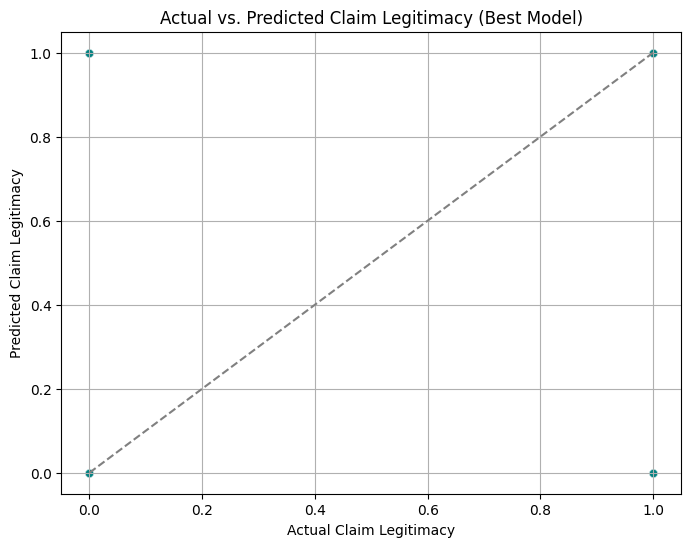

In [34]:
best_accuracy = -1
best_model_name = ''
best_model_obj = None

for res in results:
    if res['accuracy'] > best_accuracy:
        best_accuracy = res['accuracy']
        best_model_name = res['model_name']

best_model_obj = model_to_train[best_model_name]

print(f"The best performing model is {best_model_name} with an accuracy of {best_accuracy:.4f}")

#fit the best model
final_pipe = Pipeline([
    ('combine', Combine_pipe),
    ('model',best_model_obj)
])

final_pipe.fit(X_train,y_train)
y_final_pred = final_pipe.predict(X_test)


#plot Actual vs predicted
plt.figure( figsize = (8,6) )
sns.scatterplot(x=y_test, y=y_final_pred, alpha = 0.6, color='teal' )
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel("Actual Claim Legitimacy")
plt.ylabel("Predicted Claim Legitimacy")
plt.title("Actual vs. Predicted Claim Legitimacy (Best Model)")
plt.grid(True)
plt.show()

In [40]:
#voting Classification
voting_cls = VotingClassifier(
    estimators=[
        ('lr',lr),
        ('dt',dt),
        ('rf',rf),
        ('gb',gb),
        ('xgb',xgb)

    ],
    voting='soft'
)

model_lr = voting_cls
pipe_lr = Pipeline(
    steps=[
        ('combine', Combine_pipe),
        ('model', model_lr)
    ]
)
pipe_lr.fit(X_train, y_train)
y_pred_lr = pipe_lr.predict(X_test)
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.97      1.00      0.98     22875
           1       0.94      0.70      0.80      2125

    accuracy                           0.97     25000
   macro avg       0.96      0.85      0.89     25000
weighted avg       0.97      0.97      0.97     25000



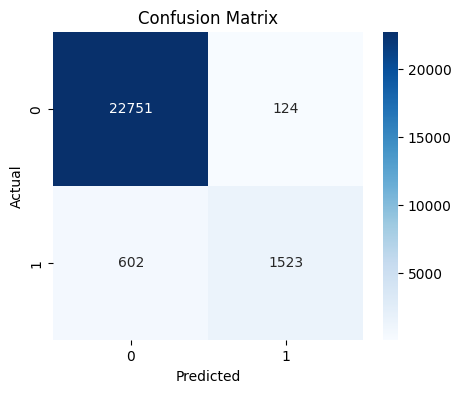

In [42]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

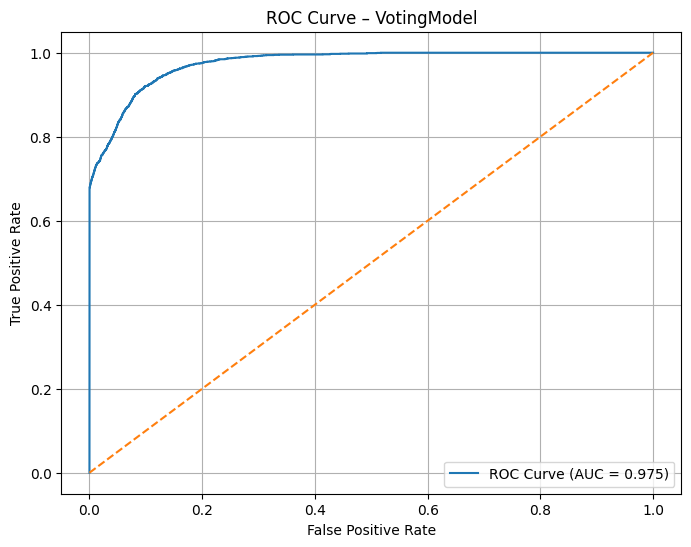

In [43]:
from sklearn.metrics import roc_curve, auc

y_prob_lr = pipe_lr.predict_proba(X_test)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_prob_lr)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.3f})")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – VotingModel")
plt.legend()
plt.grid(True)
plt.show()

In [48]:
from sklearn.model_selection import cross_val_score

In [47]:
lg_pipe = Pipeline(
    [
        ('preprocessor', Combine_pipe),
        ('model', voting_cls)
    ]
)
cross_val = cross_val_score(lg_pipe,X_train,y_train,cv=5,scoring='accuracy')
print(cross_val)

[0.97113333 0.9694     0.97       0.9714     0.9712    ]


In [50]:
print(cross_val.mean())

0.9706266666666666


In [51]:
print(cross_val.std())

0.0007849699215751893


In [52]:
cross_val_f1 = cross_val_score(lg_pipe, X_train, y_train, cv=5, scoring='f1_macro')
print("5-Fold CV F1 (macro):", cross_val_f1)
print("Mean F1:", cross_val_f1.mean())

5-Fold CV F1 (macro): [0.89391301 0.88546236 0.8884777  0.89491611 0.89462712]
Mean F1: 0.8914792620612007


In [56]:
param_grid = {'model__lr__solver': ['lbfgs', 'saga'],
              'model__lr__penalty': ['l2'],
              'model__lr__C': [0.01,0.1,1,10,100],
              'model__lr__max_iter': [1000,5000]
              }

In [65]:
print(list(lg_pipe.get_params(deep=True).keys()))

['memory', 'steps', 'transform_input', 'verbose', 'preprocessor', 'model', 'preprocessor__force_int_remainder_cols', 'preprocessor__n_jobs', 'preprocessor__remainder', 'preprocessor__sparse_threshold', 'preprocessor__transformer_weights', 'preprocessor__transformers', 'preprocessor__verbose', 'preprocessor__verbose_feature_names_out', 'preprocessor__num', 'preprocessor__cat', 'preprocessor__num__memory', 'preprocessor__num__steps', 'preprocessor__num__transform_input', 'preprocessor__num__verbose', 'preprocessor__num__imputer', 'preprocessor__num__scaler', 'preprocessor__num__imputer__add_indicator', 'preprocessor__num__imputer__copy', 'preprocessor__num__imputer__fill_value', 'preprocessor__num__imputer__keep_empty_features', 'preprocessor__num__imputer__missing_values', 'preprocessor__num__imputer__strategy', 'preprocessor__num__scaler__copy', 'preprocessor__num__scaler__with_mean', 'preprocessor__num__scaler__with_std', 'preprocessor__cat__memory', 'preprocessor__cat__steps', 'prepr

In [57]:
from sklearn.model_selection import GridSearchCV
grid_search = GridSearchCV(
    estimator=lg_pipe,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

In [58]:
grid_search.fit(X_train,y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         Index(['age', 'hypertension', 'heart_disease', 'bmi', 'HbA1c_level',
       'blood_glucose_level'],
      dtype='object')),
                                                                        ('cat',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy...
                                                                                    max_leaves=None,
                                                                                    min_child_weight=None,
                                                                                    missing=nan,
                                                                                    monotone_constraints=None,
                                                                                    multi_strategy=None,
                                                                                    n_estimators=None,
                                                                                    n_jobs=None,
                                                                                    num_parallel_tree=None, ...))],
                                                         voting='soft'))]),
             n_jobs=-1,
             param_grid={'model__lr__C': [0.01, 0.1, 1, 10, 100],
                         'model__lr__max_iter': [1000, 5000],
                         'model__lr__penalty': ['l2'],
                         'model__lr__solver': ['lbfgs', 'saga']},
             scoring='accuracy', verbose=1)

In [60]:
print("Best Parameters Found:", grid_search.best_params_)
print("Best CV Accuracy:", grid_search.best_score_)

Best Parameters Found: {'model__lr__C': 100, 'model__lr__max_iter': 5000, 'model__lr__penalty': 'l2', 'model__lr__solver': 'lbfgs'}
Best CV Accuracy: 0.9708400000000001


In [61]:
best_lr_model = grid_search.best_estimator_

In [62]:
y_pred = best_lr_model.predict(X_test)
print("Final Test Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Final Test Accuracy: 0.97096
Classification Report:
               precision    recall  f1-score   support

           0       0.97      1.00      0.98     22875
           1       0.95      0.70      0.80      2125

    accuracy                           0.97     25000
   macro avg       0.96      0.85      0.89     25000
weighted avg       0.97      0.97      0.97     25000



In [63]:
!pip install mlflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.4/49.4 kB 2.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 1.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.5/43.5 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 71.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 57.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 41.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.0/212.0 kB 13.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.3/86.3 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 935.6/935.6 kB 41.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2

In [66]:
import mlflow
import mlflow.sklearn
from sklearn.metrics import accuracy_score, classification_report

# Set experiment
mlflow.set_experiment("Mobile_Price_Prediction_LogisticRegression")

# Define parameters for LogisticRegression
my_params = {
    'C': 1.0,
    'penalty': 'l2',
    'solver': 'lbfgs',
    'max_iter': 5000,
    'multi_class': 'multinomial',
    'random_state': 42
}

# Create a LogisticRegression instance with my_params
lr_configured_for_mlflow = LogisticRegression(**my_params)

# Re-define the VotingClassifier to include the configured LogisticRegression
# Use the other base learners (dt, rf, gb, xgb) which are globally defined
voting_cls_for_mlflow_run = VotingClassifier(
    estimators=[
        ('lr', lr_configured_for_mlflow), # Use the configured LR
        ('dt', dt),
        ('rf', rf),
        ('gb', gb),
        ('xgb', xgb)
    ],
    voting='soft'
)

# pipeline
simple_lr_pipe = Pipeline([
    ('combine', Combine_pipe),
    ('model', voting_cls_for_mlflow_run) # Pass the correctly constructed VotingClassifier
])

# Start MLflow run
with mlflow.start_run(run_name="Voting_Run"):

    mlflow.log_params(my_params)
    mlflow.log_param("model_type", "Voting")

    # Train model
    simple_lr_pipe.fit(X_train, y_train)

    # Prediction
    y_train_pred = simple_lr_pipe.predict(X_train)
    y_test_pred = simple_lr_pipe.predict(X_test)

    # Evaluate
    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)

    mlflow.log_metric("train_accuracy", train_acc)
    mlflow.log_metric("test_accuracy", test_acc)

    # Log model
    mlflow.sklearn.log_model(simple_lr_pipe, "Voting_model")

    # Print results
    print("Train Accuracy:", train_acc)
    print("Test Accuracy:", test_acc)
    print("\nClassification Report:\n", classification_report(y_test, y_test_pred))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1237: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, binary problems will be fit as proper binary  logistic regression models (as if multi_class='ovr' were set). Leave it to its default value to avoid this warning.
  warnings.warn(
2026/06/10 20:55:01 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/10 20:55:01 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Train Accuracy: 0.9825466666666667
Test Accuracy: 0.9708

Classification Report:
               precision    recall  f1-score   support

           0       0.97      1.00      0.98     22875
           1       0.94      0.70      0.80      2125

    accuracy                           0.97     25000
   macro avg       0.96      0.85      0.89     25000
weighted avg       0.97      0.97      0.97     25000



In [67]:
print('Original numerical columns:', numerical_cols.tolist())
print('Original categorical columns:', categorical_cols.tolist())

# Get feature names after transformation
feature_names = Combine_pipe.get_feature_names_out()
print('\nTransformed feature names:')
for name in feature_names:
    print(name)

Original numerical columns: ['age', 'hypertension', 'heart_disease', 'bmi', 'HbA1c_level', 'blood_glucose_level']
Original categorical columns: ['gender', 'smoking_history']

Transformed feature names:
num__age
num__hypertension
num__heart_disease
num__bmi
num__HbA1c_level
num__blood_glucose_level
cat__gender_Female
cat__gender_Male
cat__gender_Other
cat__smoking_history_No Info
cat__smoking_history_current
cat__smoking_history_ever
cat__smoking_history_former
cat__smoking_history_never
cat__smoking_history_not current
